In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import zipfile

In [3]:
zip_path = "/content/drive/MyDrive/diabetes+130-us+hospitals+for+years+1999-2008.zip"

In [4]:
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extract("diabetic_data.csv", "/content/")

In [5]:
df=pd.read_csv("/content/diabetic_data.csv")

I chose the Diabetes 130-US Hospitals dataset because it is a real-world healthcare dataset with around 101,000 patient records and 50 features. It provides a multiclass classification problem where the Target is to predict hospital readmission. The dataset contains both numerical and categorical variables, missing values  which gives us scope for data preprocessing , data cleaning and feature engineering. It is also suitable for comparing different ensemble learning techniques such as Random Forest, Bagging, Gradient Boosting and XGBoost.

In [6]:
df.shape

(101766, 50)

In [7]:
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [8]:
df.tail()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO
101765,443867222,175429310,Caucasian,Male,[70-80),?,1,1,7,6,...,No,No,No,No,No,No,No,No,No,NO


In [9]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [11]:
df = df.replace("?", np.nan)

In [12]:
df.isnull().sum()

,0
encounter_id,0
patient_nbr,0
race,2273
gender,0
age,0
weight,98569
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


Data Cleaning

In [13]:
df = df.drop(columns=["encounter_id", "patient_nbr"])

In [14]:
df = df.drop(columns=["weight"])

In [15]:
df = df.drop(columns=["payer_code"])

In [16]:
df["A1Cresult"].value_counts(dropna=False)

,count
A1Cresult,
NaN,84748
>8,8216
Norm,4990
>7,3812


In [17]:
df["A1Cresult"] = df["A1Cresult"].fillna("Not_Measured")

In [18]:
df["max_glu_serum"].value_counts(dropna=False)

,count
max_glu_serum,
NaN,96420
Norm,2597
>200,1485
>300,1264


In [19]:
df["max_glu_serum"] = df["max_glu_serum"].fillna("Not_Measured")

In [20]:
df["race"] = df["race"].fillna("Unknown")

In [21]:
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

In [22]:
df["gender"].value_counts(dropna=False)

,count
gender,
Female,54708
Male,47055
Unknown/Invalid,3


In [23]:
df["gender"] = df["gender"].replace("Unknown/Invalid", np.nan)

In [25]:
df["change"].value_counts()

,count
change,
No,54755
Ch,47011


In [26]:
df["medication_changed"] = df["change"].map({
    "No": 0,
    "Ch": 1
})

In [27]:
df["diabetesMed"].value_counts()

,count
diabetesMed,
Yes,78363
No,23403


In [28]:
df["diabetes_medication"] = df["diabetesMed"].map({
    "No": 0,
    "Yes": 1
})

In [29]:
print(df["examide"].value_counts())
print(df["citoglipton"].value_counts())

examide
No    101766
Name: count, dtype: int64
citoglipton
No    101766
Name: count, dtype: int64


In [30]:
df = df.drop(columns=["examide", "citoglipton"])

In [31]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [32]:
print(df.shape)
print("\nTarget:")
print(df["readmitted"].value_counts())
print("\nUnique values:")
for col in ["race", "gender", "age", "A1Cresult", "max_glu_serum",
            "change", "diabetesMed"]:
    print(f"\n{col}:")
    print(df[col].value_counts(dropna=False))

(101766, 46)

Target:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

Unique values:

race:
race
Caucasian          76099
AfricanAmerican    19210
Unknown             2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64

gender:
gender
Female     54708
Male       47055
Unknown        3
Name: count, dtype: int64

age:
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64

A1Cresult:
A1Cresult
Not_Measured    84748
>8               8216
Norm             4990
>7               3812
Name: count, dtype: int64

max_glu_serum:
max_glu_serum
Not_Measured    96420
Norm             2597
>200             1485
>300             1264
Name: count, dtype: int64

change:
change
No    54755
Ch    47011
Name: count, dtype: int64

diabetesMed:
diabetesMed
Yes    78363
No  

EDA

UNIVARIATE ANALYSIS

READMISSION

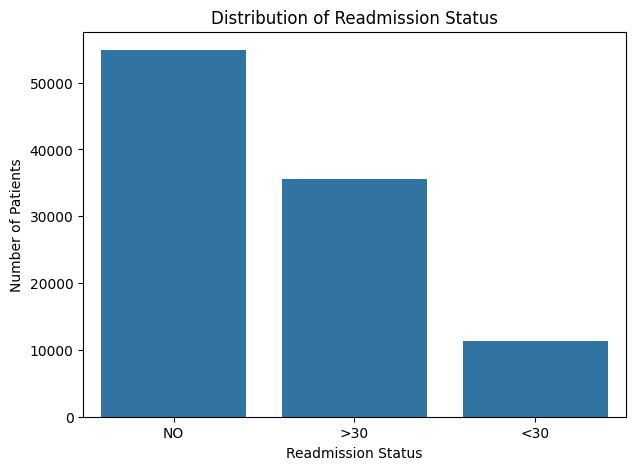

In [33]:
plt.figure(figsize=(7,5))

sns.countplot(data=df, x='readmitted')

plt.title("Distribution of Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.show()

CATEGORICAL COLUMNS

In [34]:
categorical_cols = df.select_dtypes(include='object').columns
print(categorical_cols)

Index(['race', 'gender', 'age', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide',
       'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide',
       'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
       'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
       'insulin', 'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')


GENDER

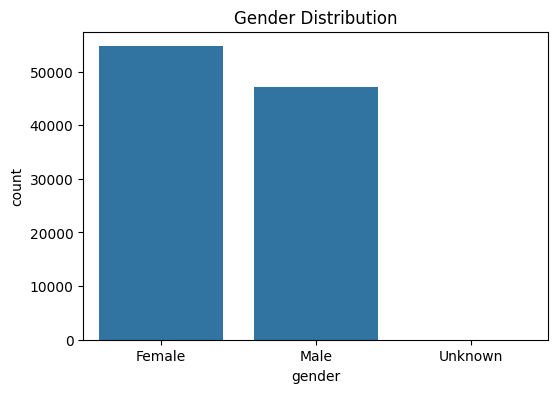

In [35]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender')
plt.title("Gender Distribution")
plt.show()

RACE DISTRIBUTION

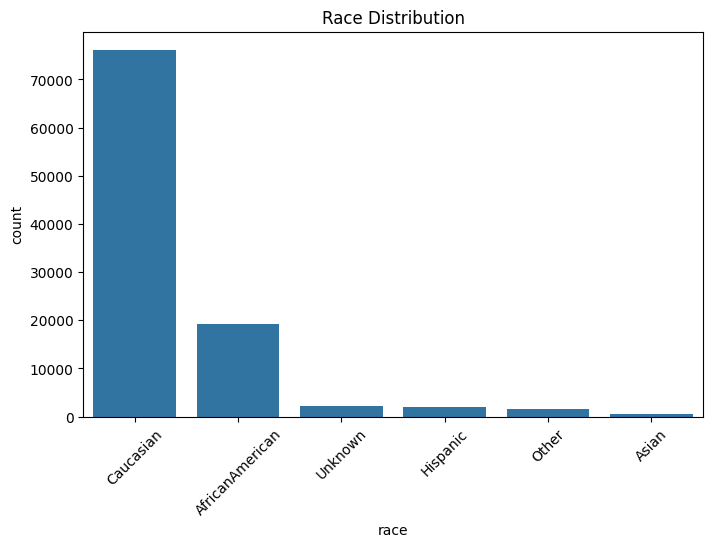

In [36]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='race', order=df['race'].value_counts().index)
plt.title("Race Distribution")
plt.xticks(rotation=45)
plt.show()

AGE GROUP

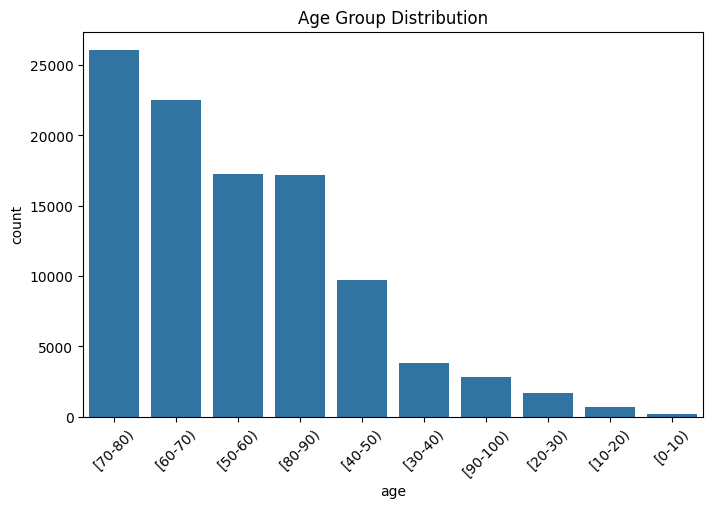

In [38]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x='age',
    order=df['age'].value_counts().index
)
plt.title("Age Group Distribution")
plt.xticks(rotation=45)
plt.show()

NUMERICAL COLUMNS

In [39]:
numeric_cols = df.select_dtypes(include=np.number).columns
print(numeric_cols)

Index(['admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'num_lab_procedures', 'num_procedures',
       'num_medications', 'number_outpatient', 'number_emergency',
       'number_inpatient', 'number_diagnoses', 'medication_changed',
       'diabetes_medication'],
      dtype='object')


TIME IN HOSPITAL

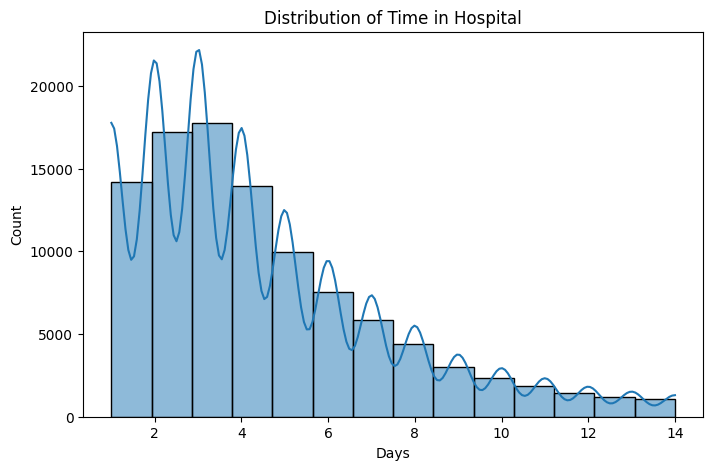

In [40]:
plt.figure(figsize=(8,5))
sns.histplot(df['time_in_hospital'], bins=14, kde=True)
plt.title("Distribution of Time in Hospital")
plt.xlabel("Days")
plt.show()

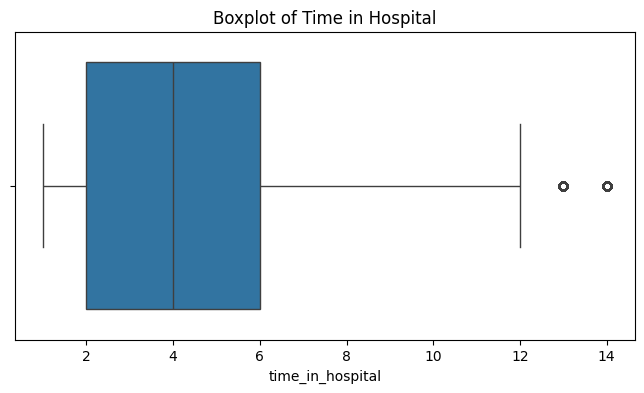

In [41]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['time_in_hospital'])
plt.title("Boxplot of Time in Hospital")
plt.show()

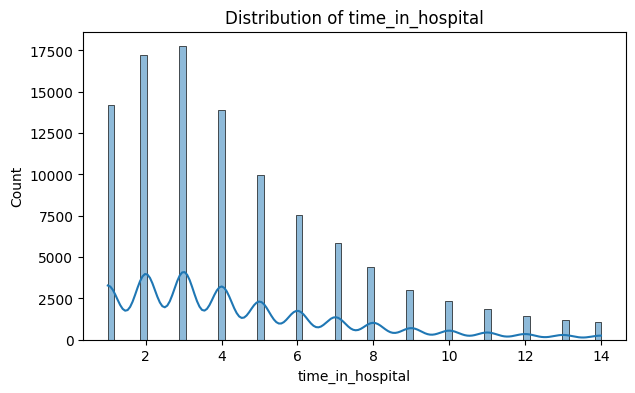

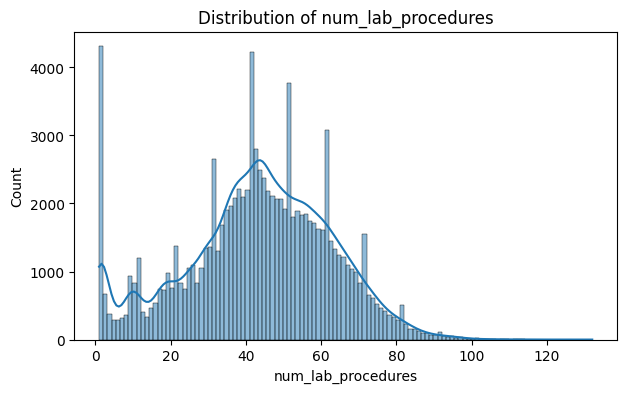

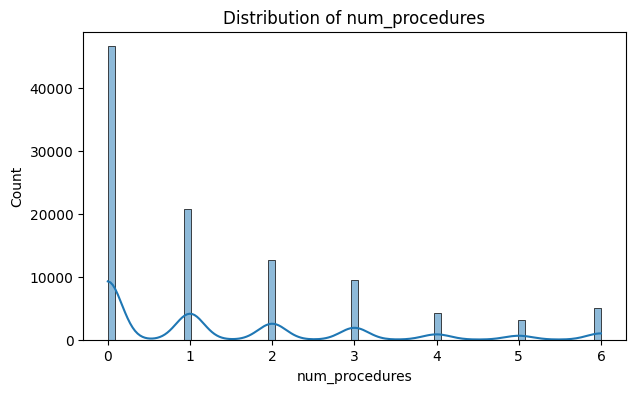

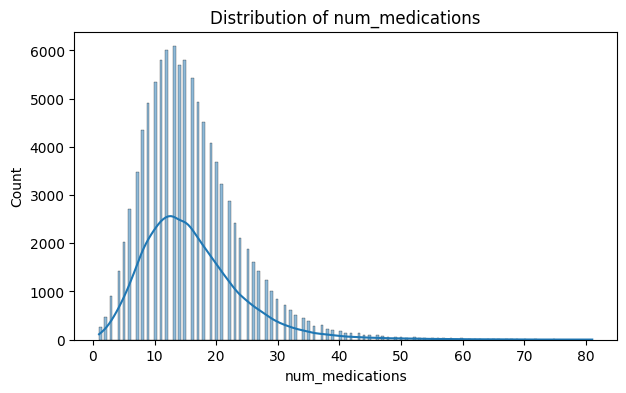

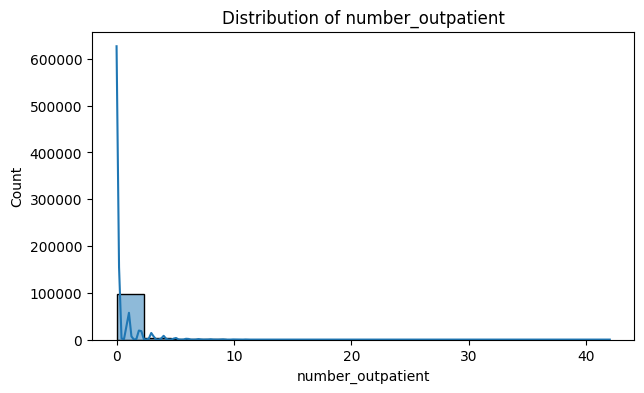

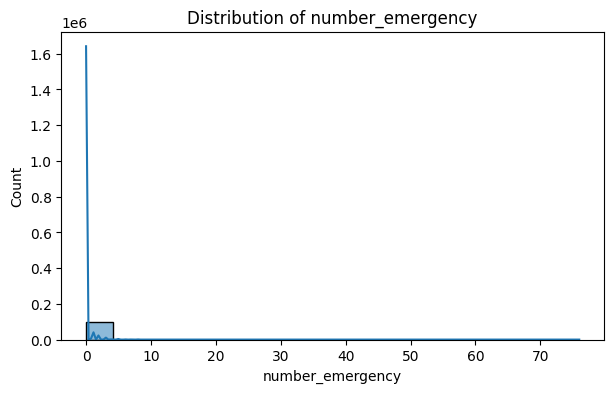

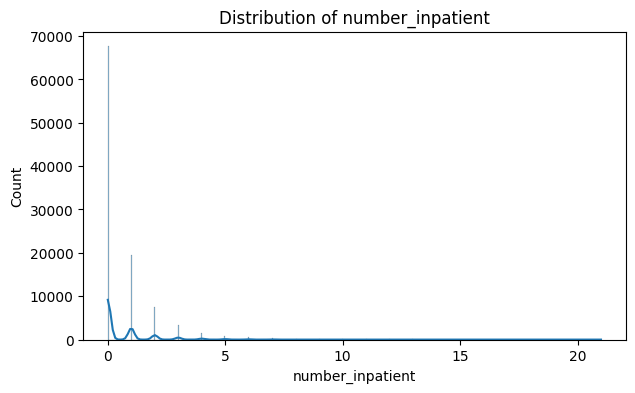

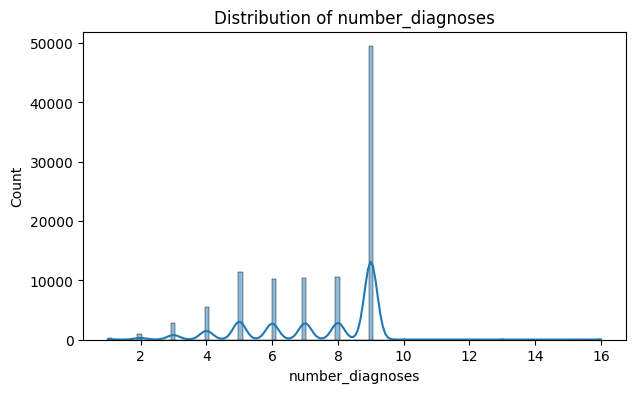

In [42]:
num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

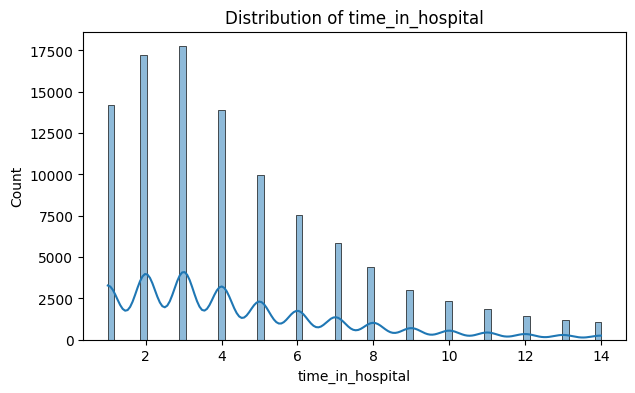

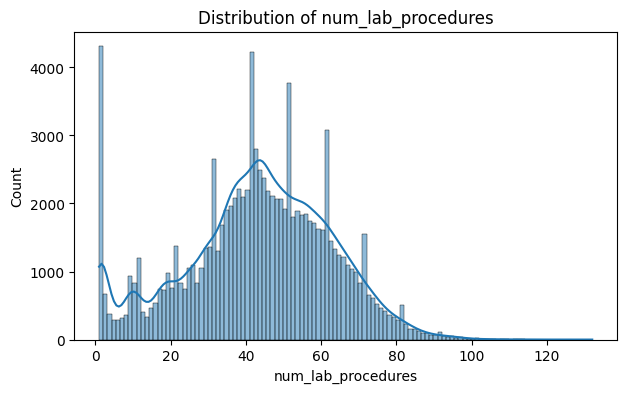

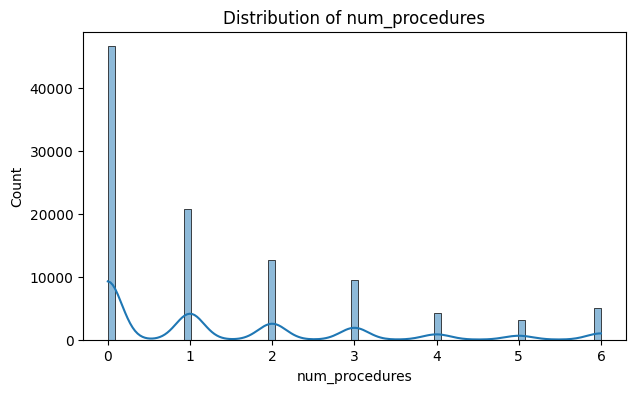

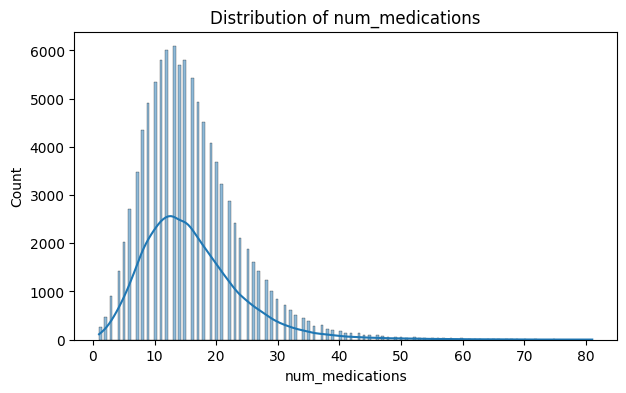

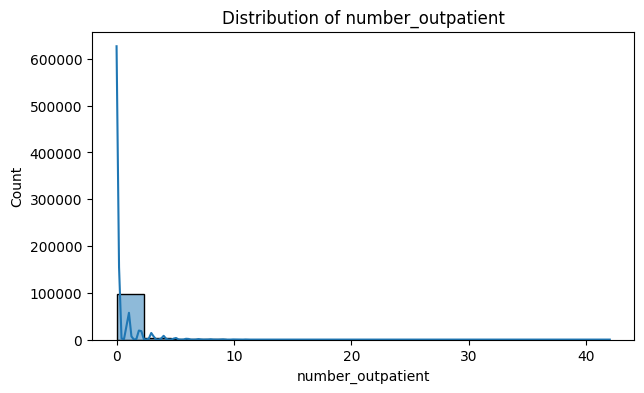

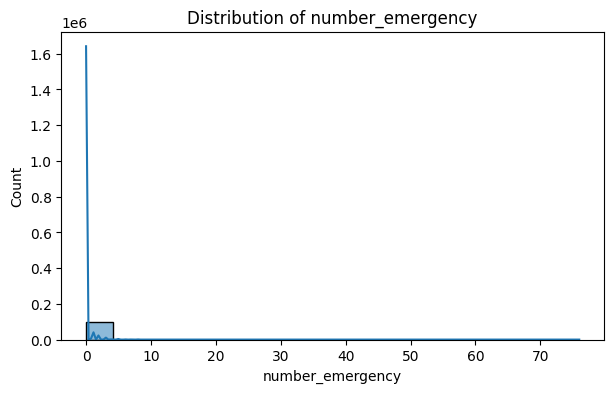

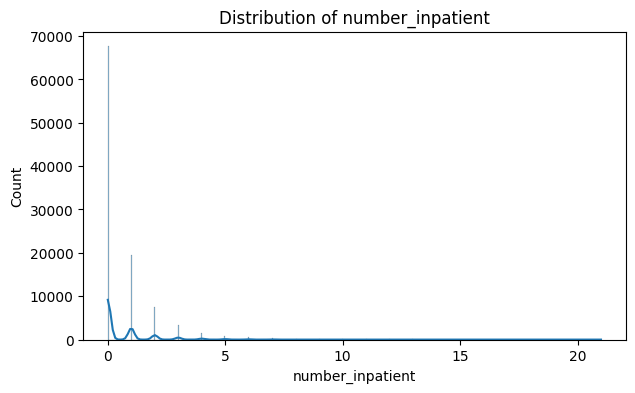

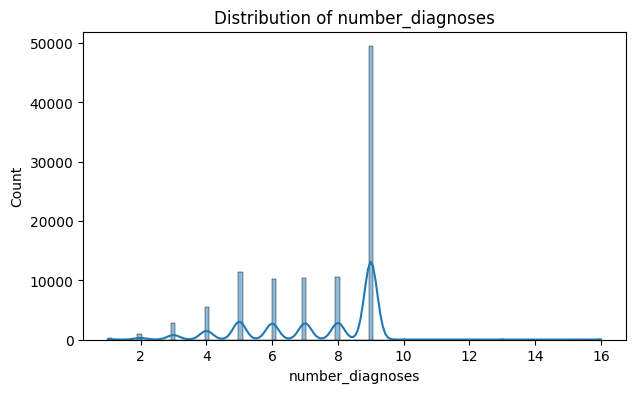

In [43]:
num_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses'
]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

NUMERICAL COLUMN BOXPLOT

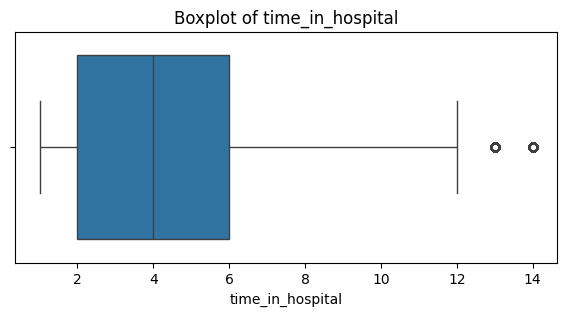

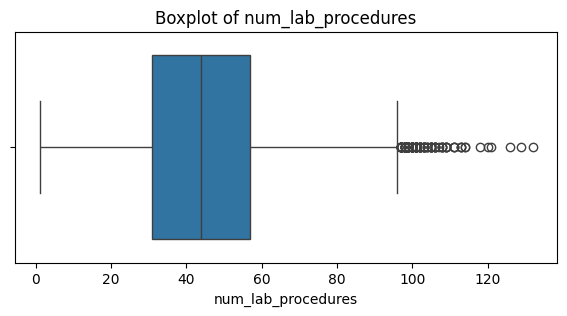

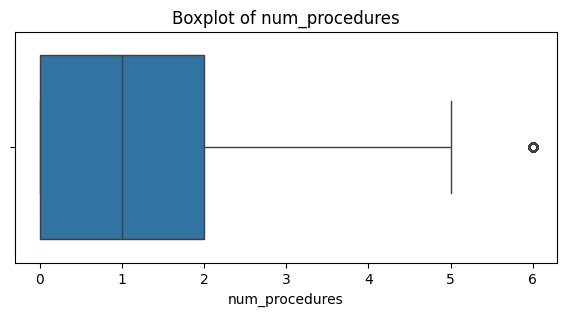

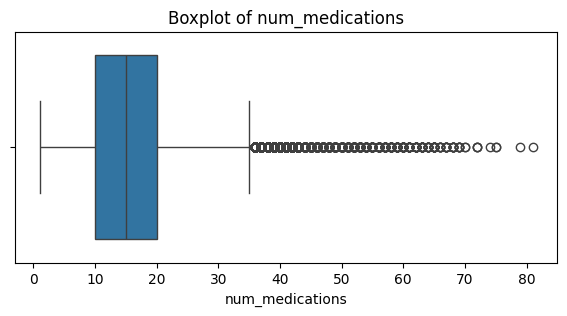

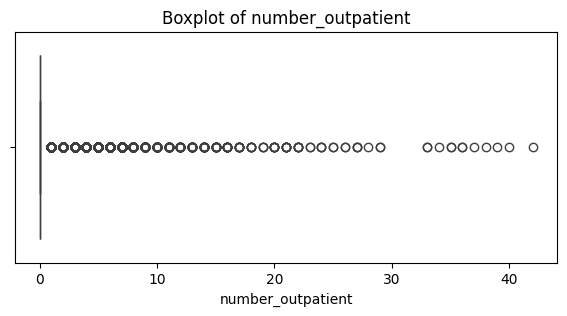

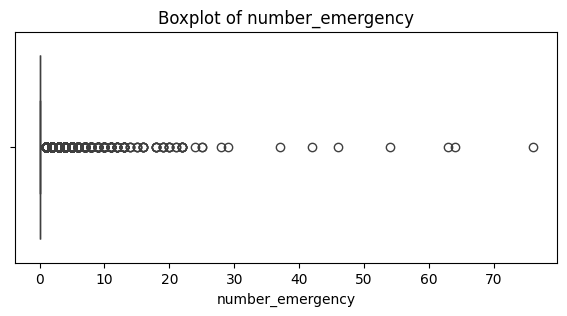

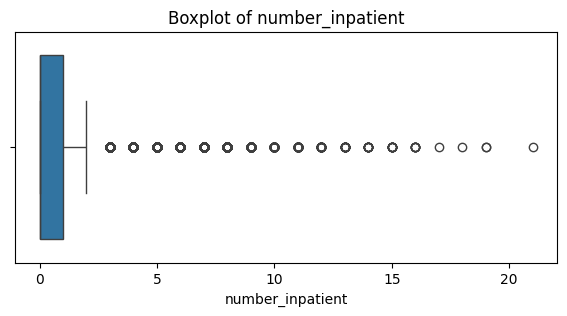

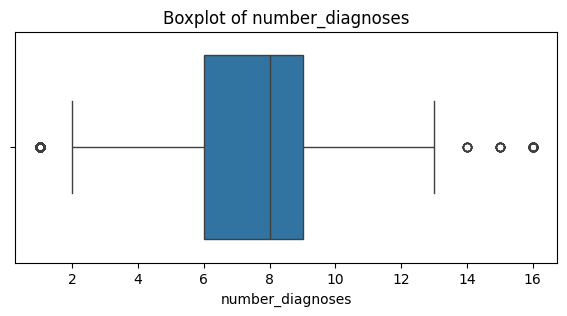

In [61]:
for col in num_cols:
    plt.figure(figsize=(7,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

BIVARIATE ANALYSIS

AGE VS READMISSION

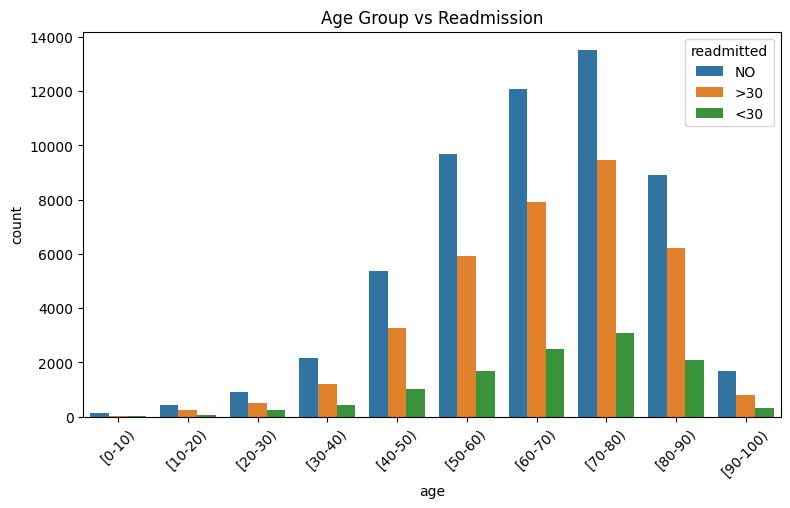

In [44]:
plt.figure(figsize=(9,5))
sns.countplot(
    data=df,
    x='age',
    hue='readmitted'
)
plt.title("Age Group vs Readmission")
plt.xticks(rotation=45)
plt.show()

GENDER VS READMISSION

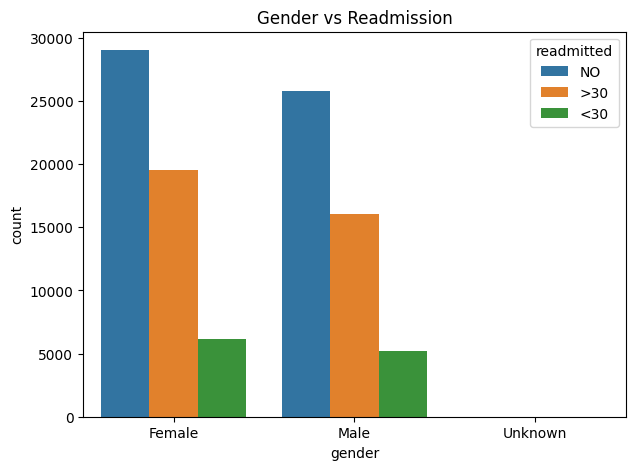

In [45]:
plt.figure(figsize=(7,5))
sns.countplot(
    data=df,
    x='gender',
    hue='readmitted'
)
plt.title("Gender vs Readmission")
plt.show()

RACE VS READMISSION

In [47]:
race_readmission = pd.crosstab(
    df['race'],
    df['readmitted'],
    normalize='index'
) * 100

display(race_readmission)

readmitted,<30,>30,NO
race,,,
AfricanAmerican,11.218116,34.534097,54.247788
Asian,10.140406,25.117005,64.742590
Caucasian,11.290556,35.643044,53.066400
Hispanic,10.407462,31.516937,58.075601
Other,9.628154,29.614874,60.756972
Unknown,8.271007,23.669160,68.059833


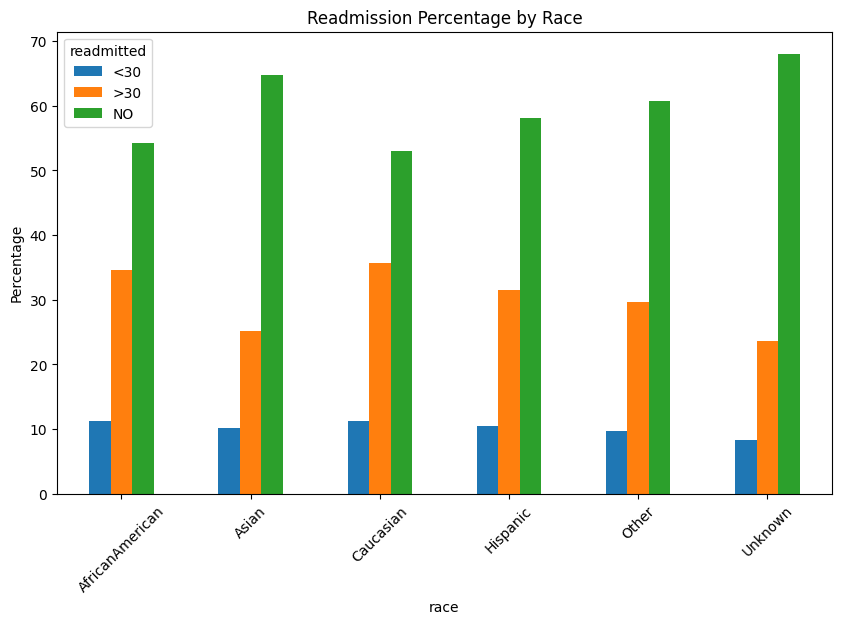

In [48]:
race_readmission.plot(
    kind='bar',
    figsize=(10,6)
)
plt.ylabel("Percentage")
plt.title("Readmission Percentage by Race")
plt.xticks(rotation=45)
plt.show()

TIME IN HOSPITAL VS READMISSION

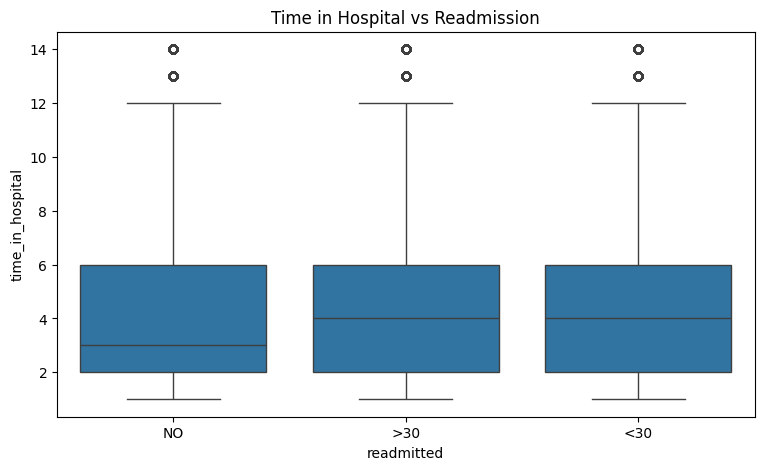

In [49]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='time_in_hospital'
)
plt.title("Time in Hospital vs Readmission")
plt.show()

NUMBER OF MEDICATION VS READMISSION

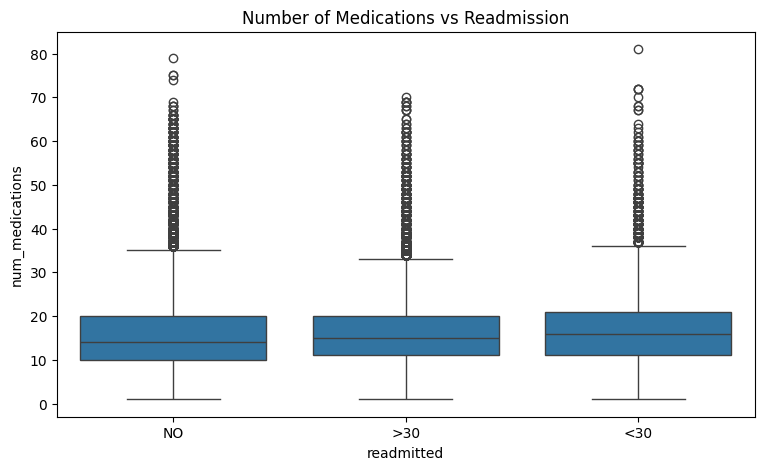

In [50]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='num_medications'
)
plt.title("Number of Medications vs Readmission")
plt.show()

NUMBER OF INPATIENT VISIT VS READMISSION

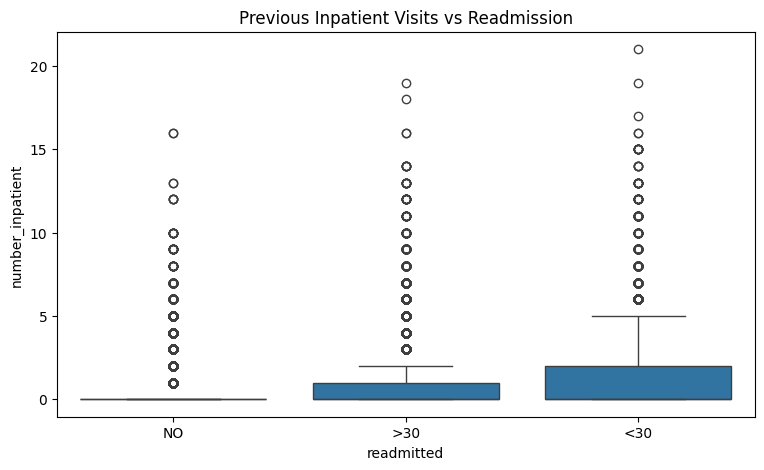

In [51]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='number_inpatient'
)
plt.title("Previous Inpatient Visits vs Readmission")
plt.show()

NUMBER OF DIAGNOSES VS READMISIION

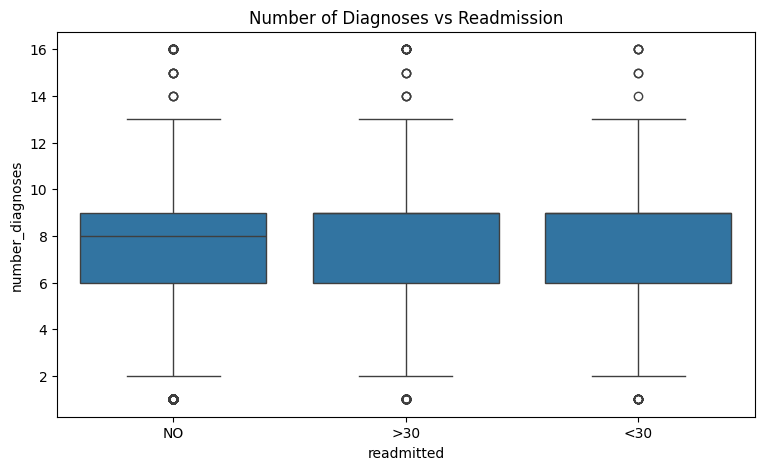

In [54]:
plt.figure(figsize=(9,5))
sns.boxplot(
    data=df,
    x='readmitted',
    y='number_diagnoses'
)

plt.title("Number of Diagnoses vs Readmission")
plt.show()

DIABETES MEDICATION VS READMISSION

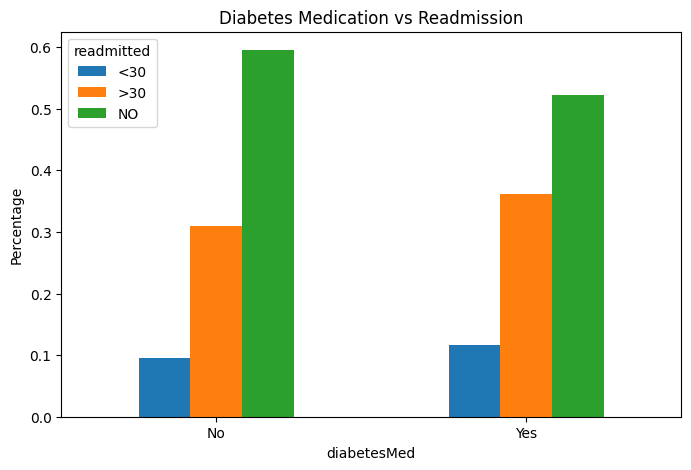

In [55]:
pd.crosstab(
    df['diabetesMed'],
    df['readmitted'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Percentage")
plt.title("Diabetes Medication vs Readmission")
plt.xticks(rotation=0)
plt.show()

INSULIN VS READMISSION

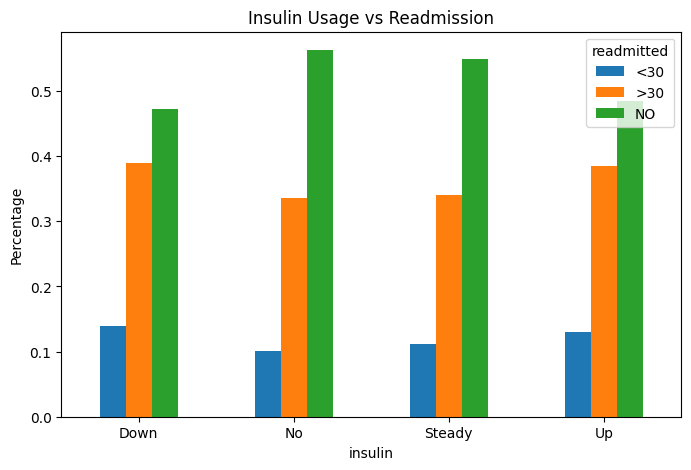

In [56]:
pd.crosstab(
    df['insulin'],
    df['readmitted'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8,5)
)
plt.ylabel("Percentage")
plt.title("Insulin Usage vs Readmission")
plt.xticks(rotation=0)
plt.show()

A1Cresult vs Readmission

In [52]:
pd.crosstab(
    df['A1Cresult'],
    df['readmitted'],
    normalize='index'
) * 100

readmitted,<30,>30,NO
A1Cresult,,,
>7,10.047219,34.102833,55.849948
>8,9.870983,35.309153,54.819864
Norm,9.659319,32.044088,58.296593
Not_Measured,11.423278,35.098173,53.478548


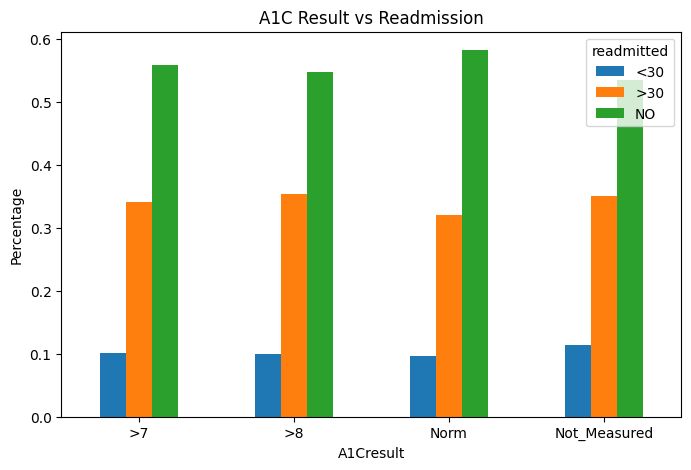

In [53]:
pd.crosstab(
    df['A1Cresult'],
    df['readmitted'],
    normalize='index'
).plot(
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("Percentage")
plt.title("A1C Result vs Readmission")
plt.xticks(rotation=0)
plt.show()

MULTIVARIATE ANALYSIS

NUMERICAL FEATURE HEATMAP

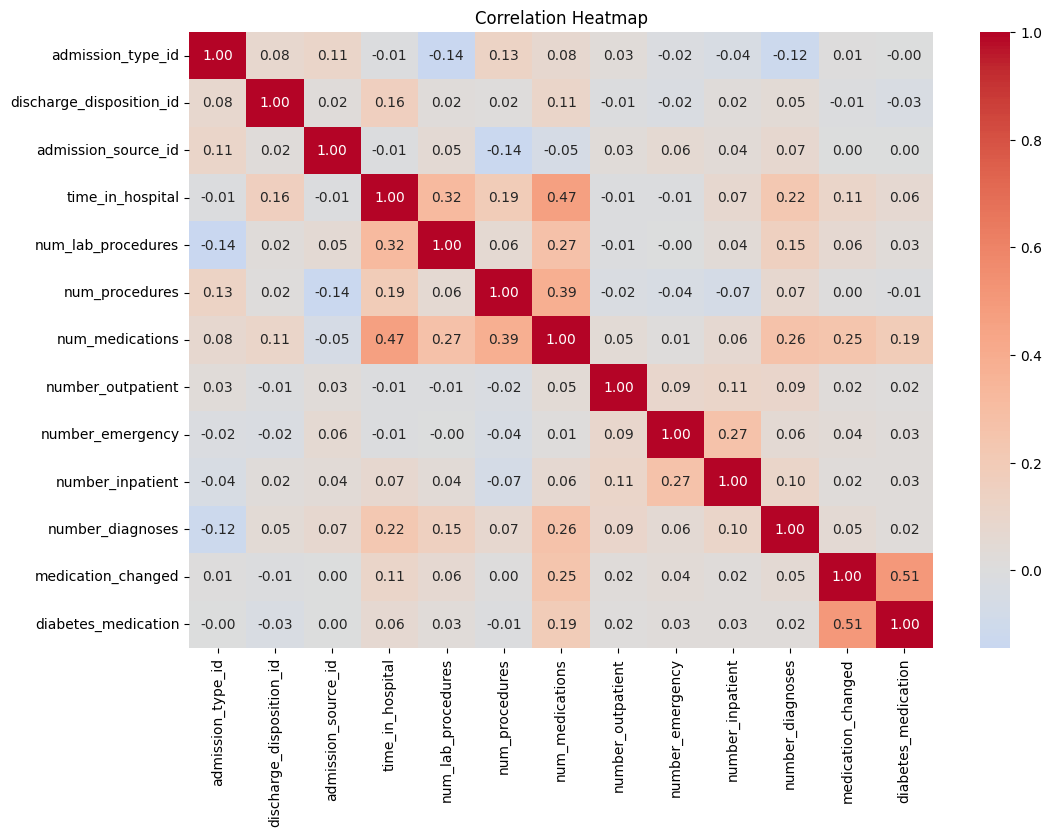

In [57]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title("Correlation Heatmap")
plt.show()

AGE VS TIME IN HOSPITAL VS READMISSION

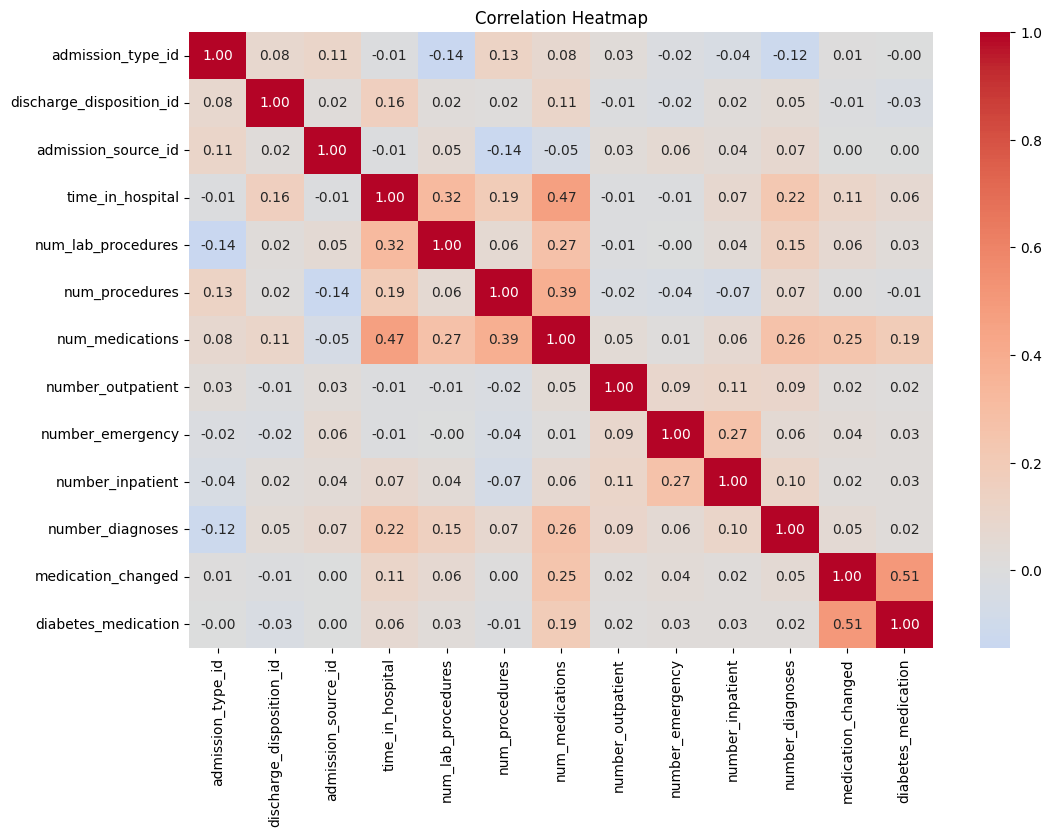

In [58]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

AGE VS NUMBER OG MEDICATION VS READMISSION

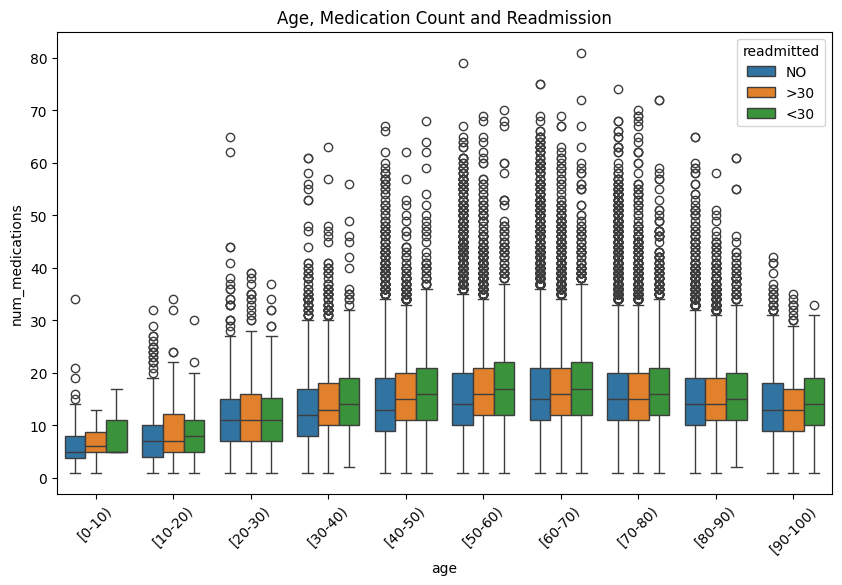

In [59]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x='age',
    y='num_medications',
    hue='readmitted'
)
plt.title("Age, Medication Count and Readmission")
plt.xticks(rotation=45)
plt.show()

PAIRPLOT

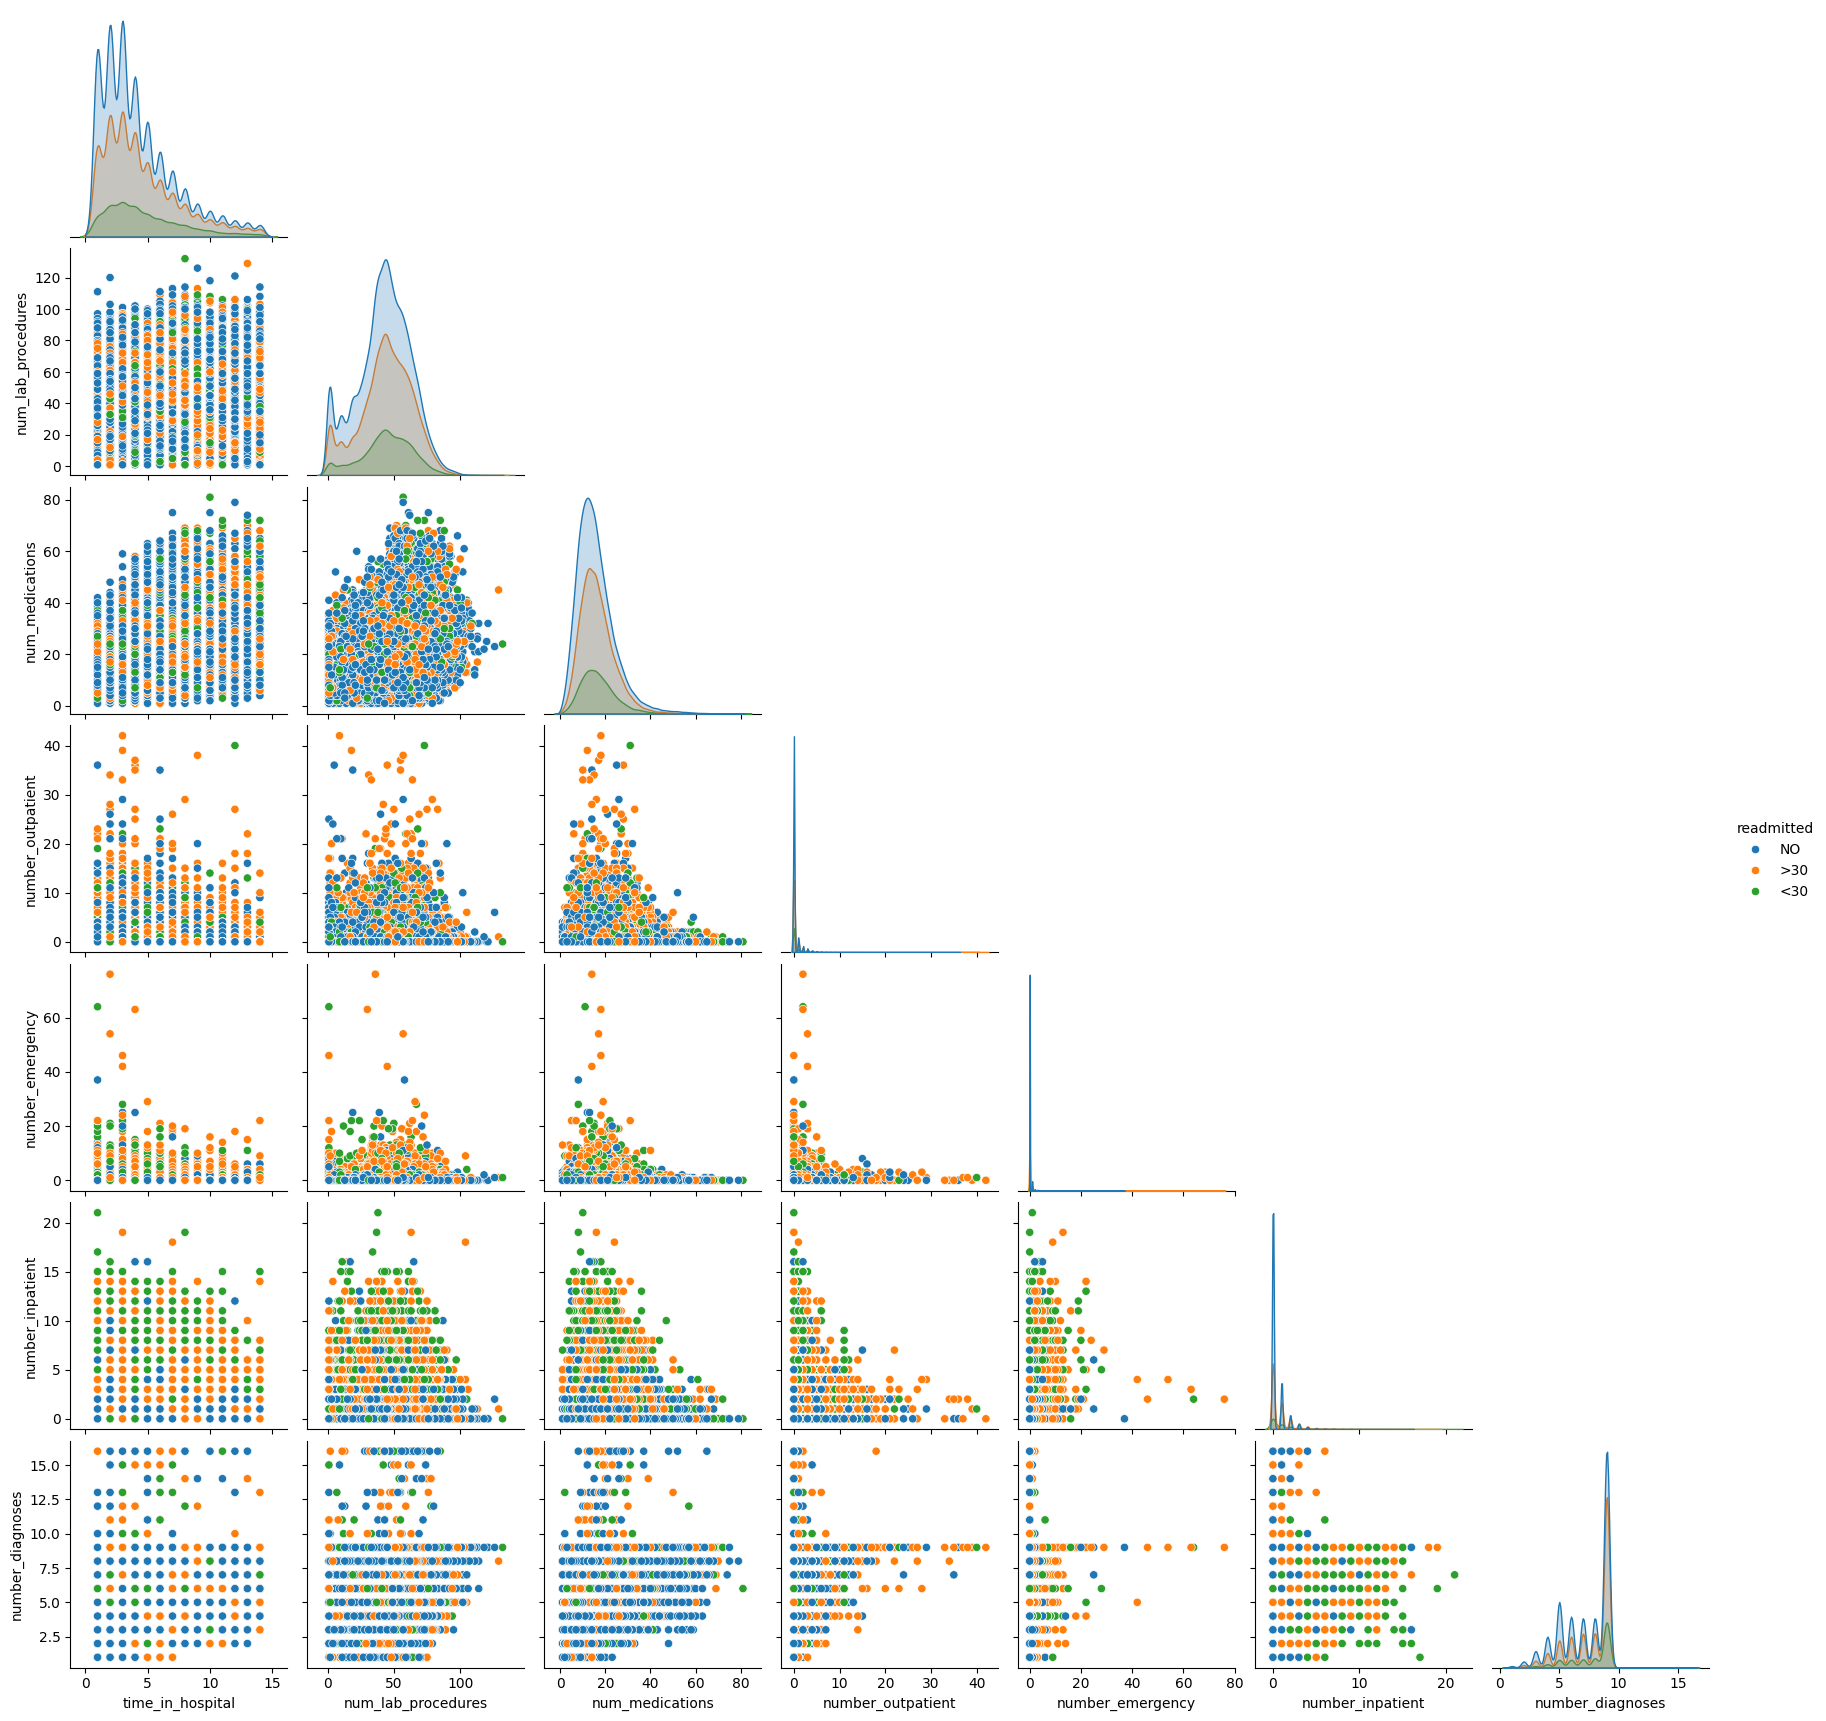

In [60]:
selected_cols = [
    'time_in_hospital',
    'num_lab_procedures',
    'num_medications',
    'number_outpatient',
    'number_emergency',
    'number_inpatient',
    'number_diagnoses',
    'readmitted'
]
sns.pairplot(
    df[selected_cols],
    hue='readmitted',
    corner=True
)
plt.show()

FEATURE ENGINEERING